KÜTÜPHANE TANIMLARI


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

GPU KONTROLÜ


In [ ]:
DATASET_PATH = "dataset"
print("Dataset var mı?", os.path.exists(DATASET_PATH))
print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU bulundu:")
    for gpu in gpus:
        print(gpu)
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth aktif edildi.")
    except RuntimeError as e:
        print(e)
else:
    print("GPU bulunamadı. Model CPU ile çalışacak.")

Dataset var mı? True
TensorFlow version: 2.20.0
GPU bulundu:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU memory growth aktif edildi.


SINIFLARI LİSTELEME, DATAFRAME OLUŞTURMA VE CLASS DAĞILIM GRAFİĞİ


Bulunan Sınıf: FaceSwap
Bulunan Sınıf: Stable Diffusion
Bulunan Sınıf: FaceShifter
Bulunan Sınıf: DALL-E
Bulunan Sınıf: StyleGAN
Bulunan Sınıf: NeuralTextures
Bulunan Sınıf: Real
Bulunan Sınıf: DeepFaceLab
Bulunan Sınıf: Midjourney
Bulunan Sınıf: Face2Face

--- Veri Seti Özeti ---
label
Real                5890
Stable Diffusion    2098
DALL-E              2000
DeepFaceLab         1606
FaceSwap            1600
FaceShifter         1000
NeuralTextures      1000
StyleGAN            1000
Face2Face           1000
Midjourney           930
Name: count, dtype: int64
Toplam görsel sayısı: 18124
Toplam class sayısı: 10


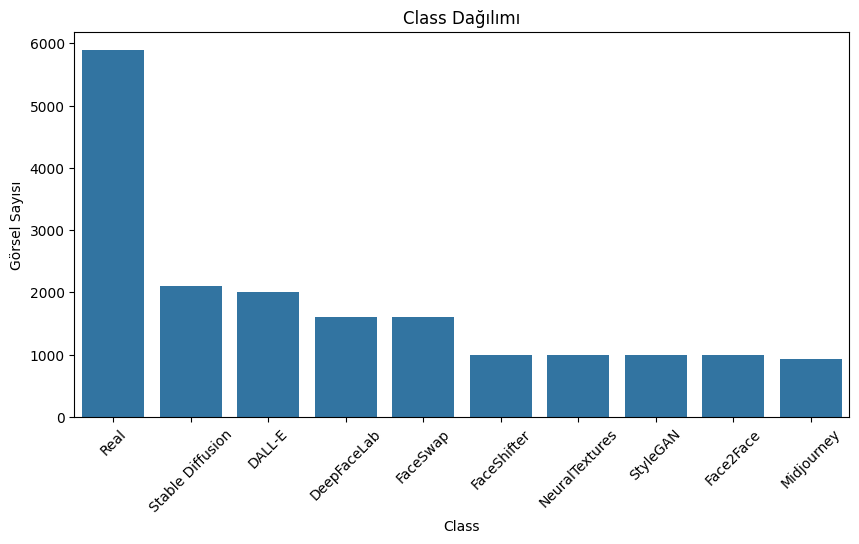

In [ ]:
for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)
    if os.path.isdir(folder_path):
        print("Bulunan Sınıf:", folder)

image_extensions = [".jpg", ".jpeg", ".png", ".webp"]
data = []

for img_path in Path(DATASET_PATH).rglob("*"):
    if img_path.suffix.lower() in image_extensions:
        label = img_path.parent.name
        data.append({
            "filepath": str(img_path),
            "label": label
        })

df = pd.DataFrame(data)

print("\n--- Veri Seti Özeti ---")
print(df["label"].value_counts())
print("Toplam görsel sayısı:", len(df))
print("Toplam class sayısı:", df["label"].nunique())

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Class Dağılımı")
plt.xlabel("Class")
plt.ylabel("Görsel Sayısı")
plt.show()

TRAIN, VALIDATION, TEST BÖLMESİ


In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

IMG_SIZE = 128
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=10, brightness_range=[0.8, 1.2])
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(dataframe=train_df, x_col="filepath", y_col="label", target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical")
val_gen = val_test_datagen.flow_from_dataframe(dataframe=val_df, x_col="filepath", y_col="label", target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False)
test_gen = val_test_datagen.flow_from_dataframe(dataframe=test_df, x_col="filepath", y_col="label", target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False)

print(train_gen.class_indices)
num_classes = len(train_gen.class_indices)
print("Class sayısı:", num_classes)

Train: 12686
Validation: 2719
Test: 2719
Found 12686 validated image filenames belonging to 10 classes.
Found 2719 validated image filenames belonging to 10 classes.
Found 2719 validated image filenames belonging to 10 classes.
{'DALL-E': 0, 'DeepFaceLab': 1, 'Face2Face': 2, 'FaceShifter': 3, 'FaceSwap': 4, 'Midjourney': 5, 'NeuralTextures': 6, 'Real': 7, 'Stable Diffusion': 8, 'StyleGAN': 9}
Class sayısı: 10


CNN MODEL MİMARİSİ VE CALLBACKS MEKANİZMASI


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(256, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ModelCheckpoint("deepfake_multiclass_cnn_final.keras", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MODEL EĞİTİMİ


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

train_class_indices = train_gen.class_indices
weight_dict = {train_class_indices[cls]: weight for cls, weight in zip(np.unique(train_df['label']), class_weights)}

history = model.fit(train_gen, validation_data=val_gen, epochs=40, callbacks=callbacks, class_weight=weight_dict)

Epoch 1/40
199/199 ━━━━━━━━━━━━━━━━━━━━ 123s 502ms/step - accuracy: 0.3464 - loss: 1.8831 - val_accuracy: 0.1159 - val_loss: 9.7171 - learning_rate: 0.0010
Epoch 2/40
199/199 ━━━━━━━━━━━━━━━━━━━━ 87s 438ms/step - accuracy: 0.5211 - loss: 1.3046 - val_accuracy: 0.2056 - val_loss: 2.6154 - learning_rate: 0.0010
Epoch 3/40
199/199 ━━━━━━━━━━━━━━━━━━━━ 88s 441ms/step - accuracy: 0.6227 - loss: 1.0591 - val_accuracy: 0.5167 - val_loss: 1.1417 - learning_rate: 0.0010
Epoch 4/40
199/199 ━━━━━━━━━━━━━━━━━━━━ 87s 438ms/step - accuracy: 0.6781 - loss: 0.9114 - val_accuracy: 0.5759 - val_loss: 1.2889 - learning_rate: 0.0010
Epoch 5/40
199/199 ━━━━━━━━━━━━━━━━━━━━ 142s 439ms/step - accuracy: 0.7210 - loss: 0.8091 - val_accuracy: 0.5248 - val_loss: 1.4128 - learning_rate: 0.0010
Epoch 6/40
199/199 ━━━━━━━━━━━━━━━━━━━━ 88s 442ms/step - accuracy: 0.7587 - loss: 0.7135 - val_accuracy: 0.6407 - val_loss: 1.0740 - learning_rate: 0.0010
Epoch 7/40
199/199 ━━━━━━━━━━━━━━━━━━━━ 87s 437ms/step - accuracy: 0

TEST DEĞERLENDİRME


In [ ]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.9643 - loss: 0.1096
Test Accuracy: 0.9643251299858093
Test Loss: 0.10960672795772552


ACCURACY, LOSS VE CONFUSION MATRIX GRAFİKLERİ VE CLASSIFICATION RAPORLAMA


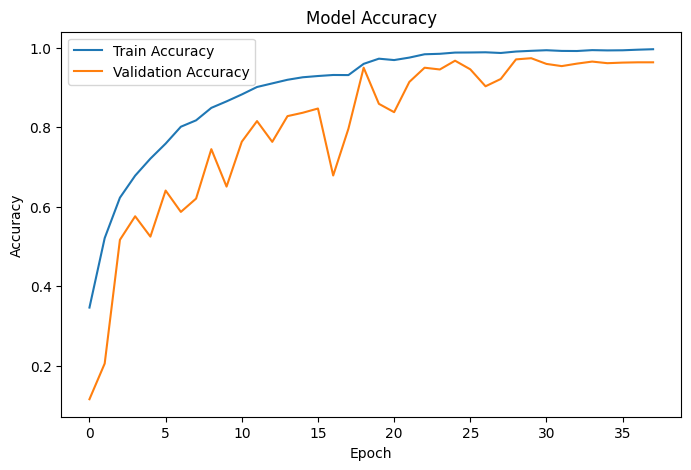

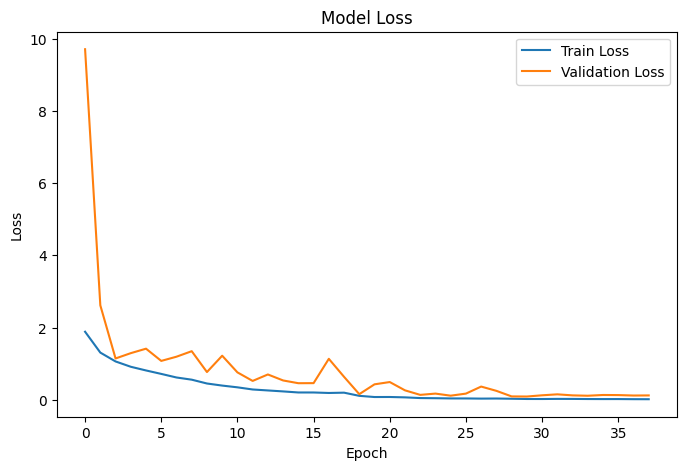

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step


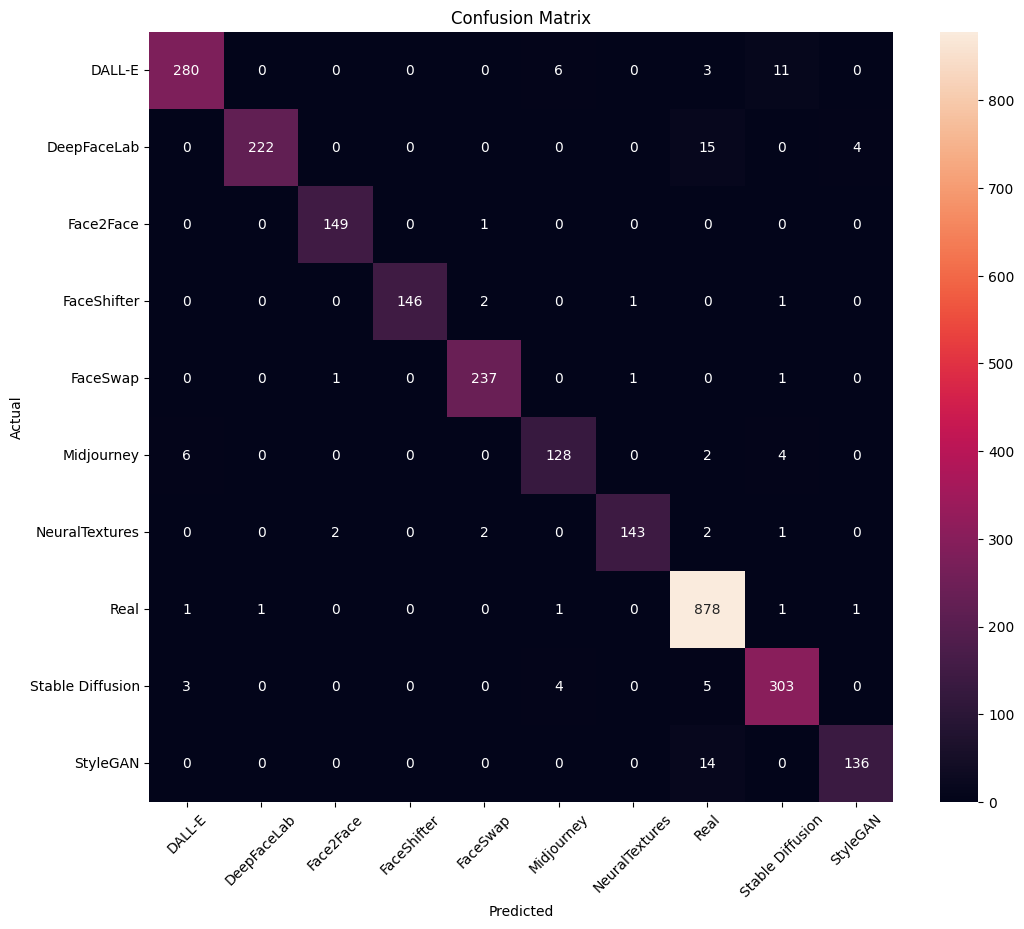

                  precision    recall  f1-score   support

          DALL-E       0.97      0.93      0.95       300
     DeepFaceLab       1.00      0.92      0.96       241
       Face2Face       0.98      0.99      0.99       150
     FaceShifter       1.00      0.97      0.99       150
        FaceSwap       0.98      0.99      0.98       240
      Midjourney       0.92      0.91      0.92       140
  NeuralTextures       0.99      0.95      0.97       150
            Real       0.96      0.99      0.97       883
Stable Diffusion       0.94      0.96      0.95       315
        StyleGAN       0.96      0.91      0.93       150

        accuracy                           0.96      2719
       macro avg       0.97      0.95      0.96      2719
    weighted avg       0.96      0.96      0.96      2719



In [17]:
# Accuracy Grafiği
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Grafiği
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Confusion Matrix ve Raporlama
pred_probs = model.predict(test_gen)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_gen.classes
class_names = list(test_gen.class_indices.keys())

cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

print(classification_report(true_classes, pred_classes, target_names=class_names))

TAHMİN FONKSİYONU


In [ ]:
def predict_single_image_with_plot(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)[0]
    index_to_class = {v: k for k, v in train_gen.class_indices.items()}
    class_names = [index_to_class[i] for i in range(len(predictions))]
    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]

    plt.figure(figsize=(10,5))
    sns.barplot(x=class_names, y=predictions)
    plt.title("Class Olasılıkları")
    plt.xlabel("Class")
    plt.ylabel("Probability")
    plt.show()

    print("Tahmin:", predicted_class)
    if predicted_class.lower() == "real":
        print("Sonuç: Gerçek görsel")
    else:
        print("Sonuç: Sahte görsel")
        print("AI Kaynağı:", predicted_class)

sample_img = test_df.iloc[281]["filepath"] 
print("Gerçek label:", test_df.iloc[281]["label"])
predict_single_image_with_plot(sample_img)